In [61]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def mat2pix(m, n, dx, dy, x, y):
    """
    m, n - size of the image in pixels
    dx, dy - size of the image in math coordinates
    x, y - math coordinates of the point
    """
    transformMatrix = np.array([[1 / dx, 0, 0.5 * m], [0, -1 / dy, 0.5 * n], [0, 0, 1]])

    pixelCoords = np.dot(transformMatrix, np.array([x, y, 1]))
    # KONWERSJA DO INT jest ważna dla funkcji cv2.fillPoly
    # poza tym tak jest bardziej logicznie, ponieważ współrzędne pikseli powinny być liczbami całkowitymi
    px = int(round(pixelCoords[0] / pixelCoords[2]))
    py = int(round(pixelCoords[1] / pixelCoords[2]))
    return px, py


def pix2mat(m, n, dx, dy, u, v):
    transformMatrix = np.array(
        [[dx, 0, -0.5 * m * dx], [0, -dy, 0.5 * n * dy], [0, 0, 1]]
    )

    mathCords = np.dot(transformMatrix, np.array([u, v, 1]))
    return (mathCords[0] / mathCords[2]), (mathCords[1] / mathCords[2])


def distance2plane(point, A, b, c, d):
    """
    Oblicza odległość punktu 3D od płaszczyzny oraz wyznacza punkt na płaszczyźnie,
    który jest rzutem prostopadłym danego punktu.

    Argumenty:
    point : array-like o długości 3
        Punkt 3D w postaci [x, y, z].
    A, b, c, d : float
        Współczynniki równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Zwraca:
    tuple[float, np.ndarray]
        - float: Nieujemna odległość punktu od płaszczyzny.
        - np.ndarray: Punkt 3D na płaszczyźnie (rzut prostopadły danego punktu).

    Wyjątki:
    ValueError
        Gdy wektor normalny płaszczyzny ma długość zero.
    """
    point = np.asarray(point, dtype=float)
    x, y, z = point

    mianownik = A**2 + b**2 + c**2

    if np.isclose(mianownik, 0.0):
        raise ValueError(
            "Nieprawidłowa płaszczyzna: A, b, c nie mogą być jednocześnie zerowe."
        )

    licznik = A * x + b * y + c * z + d

    # Parametr t dla punktu na płaszczyźnie (rzut prostopadły)
    t = -licznik / mianownik

    # Współrzędne punktu na płaszczyźnie
    x_plane = x + t * A
    y_plane = y + t * b
    z_plane = z + t * c
    plane_point = np.array([x_plane, y_plane, z_plane])

    # Odległość
    distance = np.abs(licznik) / np.sqrt(mianownik)

    return float(distance), plane_point


In [62]:
class Point:
    def __init__(self, x, y, z):
        self.coords = np.array([x, y, z])

    def __getitem__(self, index):
        return self.coords[index]


class Triangle:
    def __init__(self, p1: Point, p2: Point, p3: Point):
        self.p1 = p1
        self.p2 = p2
        self.p3 = p3
        self.epsilon = 1


class Light:
    def __init__(self, position: Point, intensity: float):
        self.position = position
        self.intensity = intensity

In [63]:
def DrawTriangleWithLambert(
    Image, Triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
):

    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    # aby skrócić kod, korzystam z funkcji fillPoly z biblioteki cv2 zamiast z ręcznie pisanych funkcji
    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    # plt.imshow(imgCopy)
    # plt.axis("off")
    # plt.title(
    #     f"Maska trójkąta: {Triangle.p1.coords}, {Triangle.p2.coords}, {Triangle.p3.coords}"
    # )
    # plt.show()
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            final_intensity = AMBIENT_LIGHT
            # pomijamy piksele nie należące do trójkąta
            if not np.all(imgCopy[y, x] == 255):
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            distance, plane_point = distance2plane((X_world, Y_world, 0), A, B, C, D)

            for light in Lights:
                light_vector = light.position.coords - plane_point
                # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(triangle_normal, light_vector_normalized)
                final_intensity += (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )
            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image


In [64]:
def DrawTriangleWithPhong(
    Image,
    Triangle,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    eye_position,
):

    imgCopy = np.zeros_like(Image)
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            final_intensity = AMBIENT_LIGHT
            # pomijamy piksele nie należące do trójkąta
            if not imgCopy[y, x][0] == 255:
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            distance, plane_point = distance2plane((X_world, Y_world, 0), A, B, C, D)

            for light in Lights:
                light_vector = light.position.coords - plane_point
                # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(triangle_normal, light_vector_normalized)

                labmert_diffuse = (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )

                reflection_vector = (
                    2 * angle_cos * triangle_normal - light_vector_normalized
                )

                eye_vector = eye_position.coords - plane_point
                eye_vector_normalized = eye_vector / np.linalg.norm(eye_vector)
                specular_dot = np.dot(reflection_vector, eye_vector_normalized)
                specular_contribution = (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * (max(specular_dot, 0) ** 15)
                )

                final_intensity += labmert_diffuse + specular_contribution

            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

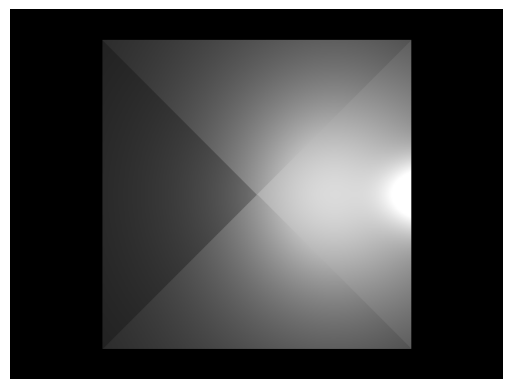

In [65]:
Triangles = [
    Triangle(Point(0, 0, 10), Point(20, 20, 20), Point(20, -20, 20)),
    Triangle(Point(0, 0, 10), Point(20, -20, 20), Point(-20, -20, 20)),
    Triangle(Point(0, 0, 10), Point(-20, -20, 20), Point(-20, 20, 20)),
    Triangle(Point(0, 0, 10), Point(-20, 20, 20), Point(20, 20, 20)),
]

Lights = [Light(Point(10, 0, 0), 235)]

Eye_position = Point(65, 0, 0)

ROZDZIELCZOSC_X = 640
ROZDZIELCZOSC_Y = 480
DX = 0.1
DY = 0.1

AMBIENT_LIGHT = 20

image = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
imagePhong = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)

# for each triangle add it to the scene with light calculated
for triangle in Triangles:
    # image = DrawTriangleWithLambert(
    #     image, triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
    # )
    imagePhong = DrawTriangleWithPhong(
        imagePhong,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
        Eye_position,
    )

# plt.imshow(image)
# plt.axis("off")
# plt.show()

plt.imshow(imagePhong)
plt.axis("off")
